In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import itertools as itr
import numpy as np
from sklearn.metrics import mean_squared_error
from random import randrange
import json

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.func import functional_call, vmap, vjp, jvp, grad

from scipy.linalg import svdvals, norm
from scipy.special import softmax
from scipy.optimize import minimize_scalar

from common.const import DATASET_PATH
from common.util import *
from common.ffn_model.minst.ffn_minst_util import MetaData
from common.ffn_model.minst.ffn_minst_optimise import \
    StepCalculatorZhangLambda, StepCalculatorEtaSoftmaxArmihoNorm2, StepCalculatorEtaSoftmaxArmihoNorm1\
        , StepCalculatorEtaSoftmaxArmihoNorm2Base, StepCalculatorEtaSoftmaxArmihoNorm1Base\
        , StepCalculatorZhangSimplified, reduce_to_active
from common.ffn_model.minst.ffn_minst_relu import MNISTReLU

from torchvision.datasets import EMNIST
#from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_eminst_epoch1d.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")
                #datefmt="%Y-%m-%d %H:%M:%S,%(msecs)")
                #datefmt="%d/%m/%Y %I:%M:%S")


#### EMNIST dataset

In [3]:
# use it to conver from PIL to torch.Tensor
image_transform = ToTensor()

train_dataset = EMNIST(root=DATASET_PATH, split='letters', train=True, download=True, transform=image_transform)
test_dataset = EMNIST(root=DATASET_PATH, split='letters', train=False, download=True, transform=image_transform)
#train_dataset = MNIST(root=DATASET_PATH, train=True, download=True, transform=image_transform)
#test_dataset = MNIST(root=DATASET_PATH, train=False, download=True, transform=image_transform)

In [4]:
BATCH_SIZE = 128 #96 #192 #96 #96 #128 #64 #

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
)

#### Metadata:

In [5]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.0
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM = 28 * 28
OUTPUT_DIM = 26 #26  # num of classes

INPUT_WIDTH, HIDDEN_WIDTH = 1000, 400 #2000, 800 #1024, 128 #1000, 400 #500, 200 #1000, 400 #500, 200 #250, 100

lb, lw = 0.005, 5.0  #1e-2, 7.5 #1e-2,1,1 #1e-2, 1e-2, 1
meta = MetaData(input_dim = INPUT_DIM, input_width = INPUT_WIDTH, hidden_width = HIDDEN_WIDTH, output_dim = OUTPUT_DIM\
                , batch_size = BATCH_SIZE, lb = lb, lw = lw)

DEVICE = torch.device('cpu')  # change to `cuda:0` when available

NUM_EPOCH = 1 #00

##### UTILS

In [ ]:
def visualise(history_params):
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes[0, 0].set_title('Loss (cross-entropy)')
    axes[0, 0].plot(history_params['train_loss'], label='Train Loss')
    axes[0, 0].plot(history_params['test_loss'], label='Test Loss')
    axes[0, 0].grid()
    axes[0, 0].legend(fontsize=20)
    
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].plot(history_params['train_accuracy'], label='Train Accuracy')
    axes[0, 1].plot(history_params['test_accuracy'], label='Test Accuracy')
    axes[0, 1].grid()
    axes[0, 1].legend(fontsize=20)

    axes[1, 0].set_title('Train-step eta')
    axes[1, 0].plot(history_params['train_eta'])
    axes[1, 0].grid()
    #ax2.legend(fontsize=20)

    axes[1, 1].set_title('Singular values for flattened NTK')
    #axes[1, 1].plot(history_params['ntk_sungular_min'], label='Singular min value')
    axes[1, 1].plot(history_params['train_ntk_sungular_max'], label='Singular max value')
    axes[1, 1].grid()
    axes[1, 1].legend(fontsize=20)
    
    plt.show()


#### Experiment 1: FFN with criticality-relu; adaptive step with 2-norm net_line/straight_line, direct parameters update

In [7]:
HISTORY_PARAMS_N2LAMBDA = collections.defaultdict(list)

testNet = MNISTReLU(meta)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
testNet.init_weights(cb, cw)
testNet.to(DEVICE)

FeedForwardNet created with n0=784, nk=0, nl=26, l=0, bias_on=True


MNISTReLU(
  (input_fc): Linear(in_features=784, out_features=1000, bias=True)
  (hidden_fc): Linear(in_features=1000, out_features=400, bias=True)
  (output_fc): Linear(in_features=400, out_features=26, bias=True)
)

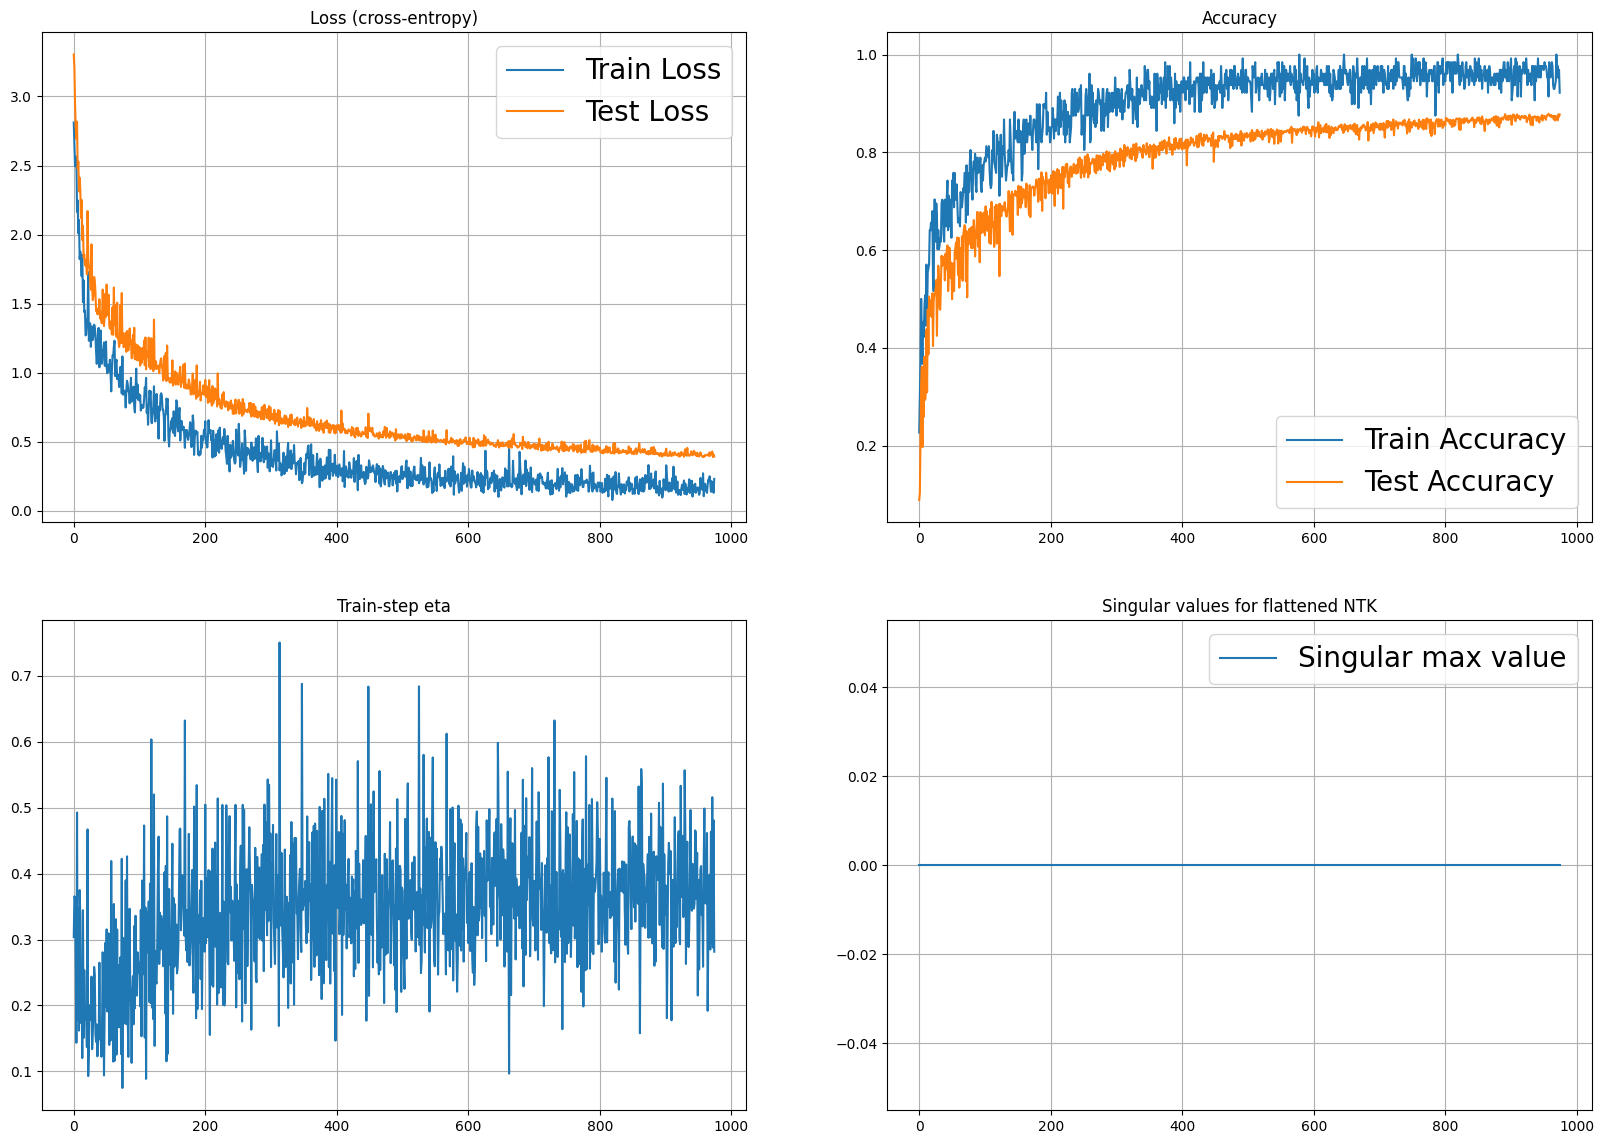

On epoch = 0 test accuracy = 0.8773485429447853


In [8]:
#stepCalcZhL = StepCalculatorZhangLambda(meta)
#stepCalcZhS = StepCalculatorZhangSimplified(meta)
#stepCalcSoftmax1 = StepCalculatorEtaSoftmaxArmihoNorm1Base(meta)
stepCalcSoftmax2 = StepCalculatorEtaSoftmaxArmihoNorm2(meta)
for epoch in range(NUM_EPOCH):
    # training loop
    iter_number = 0
    for train_batch in train_dataloader:
        iter_number += 1
        images, labels_raw = train_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)

        with torch.no_grad():
            logits = testNet.forward_(xx)
            logits_detached = logits.detach().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0))
            qq_active = reduce_to_active(qq, pp)

        qq_active_avg = np.average(qq_active)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg))
        #if qq_active_avg > 0.3:
        logging.info("##Step with Softmax2 optim")
        eta, logits_latest = stepCalcSoftmax2.step(testNet, logits_detached, labels, xx)
        #else:
        logits_latest = logits_latest.detach()

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)
        # save average train loss and accuracy
        HISTORY_PARAMS_N2LAMBDA['train_loss'].append(loss)
        HISTORY_PARAMS_N2LAMBDA['train_accuracy'].append(calculate_accuracy(prediction,labels))
        HISTORY_PARAMS_N2LAMBDA['train_eta'].append(eta)
        HISTORY_PARAMS_N2LAMBDA['train_ntk_sungular_max'].append(0)

        # testing loop
        test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
        for test_batch in test_dataloader:
            images, labels_raw = test_batch
            labels = torch.tensor([x-1 for x in labels_raw])
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.no_grad():
                batch_size = images.shape[0]
                xx = images.view(batch_size, -1)
                logits = testNet.forward_(xx)

                zz_logits = np.transpose(logits.detach().numpy())
                prediction = logits.argmax(dim=-1).detach()
                loss = loss_crossentropy(zz_logits, labels)
                test_loss_meter.update(loss)
                test_accuracy_meter.update(calculate_accuracy(prediction, labels))

        # save average test accuracy loss and accuracy
        HISTORY_PARAMS_N2LAMBDA['test_loss'].append(test_loss_meter.avg)
        HISTORY_PARAMS_N2LAMBDA['test_accuracy'].append(test_accuracy_meter.avg)
        
        visualise(HISTORY_PARAMS_N2LAMBDA)
        print("On epoch = {} test accuracy = {}".format(epoch, test_accuracy_meter.avg))




#### Experiment 1a: FFN with criticality-relu; adaptive step with 2-norm net_line/straight_line, direct parameters update, λ_μν=I

In [9]:
HISTORY_PARAMS_N2SIMPLE = collections.defaultdict(list)

testNet = MNISTReLU(meta)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
testNet.init_weights(cb, cw)
testNet.to(DEVICE)

FeedForwardNet created with n0=784, nk=0, nl=26, l=0, bias_on=True


MNISTReLU(
  (input_fc): Linear(in_features=784, out_features=1000, bias=True)
  (hidden_fc): Linear(in_features=1000, out_features=400, bias=True)
  (output_fc): Linear(in_features=400, out_features=26, bias=True)
)

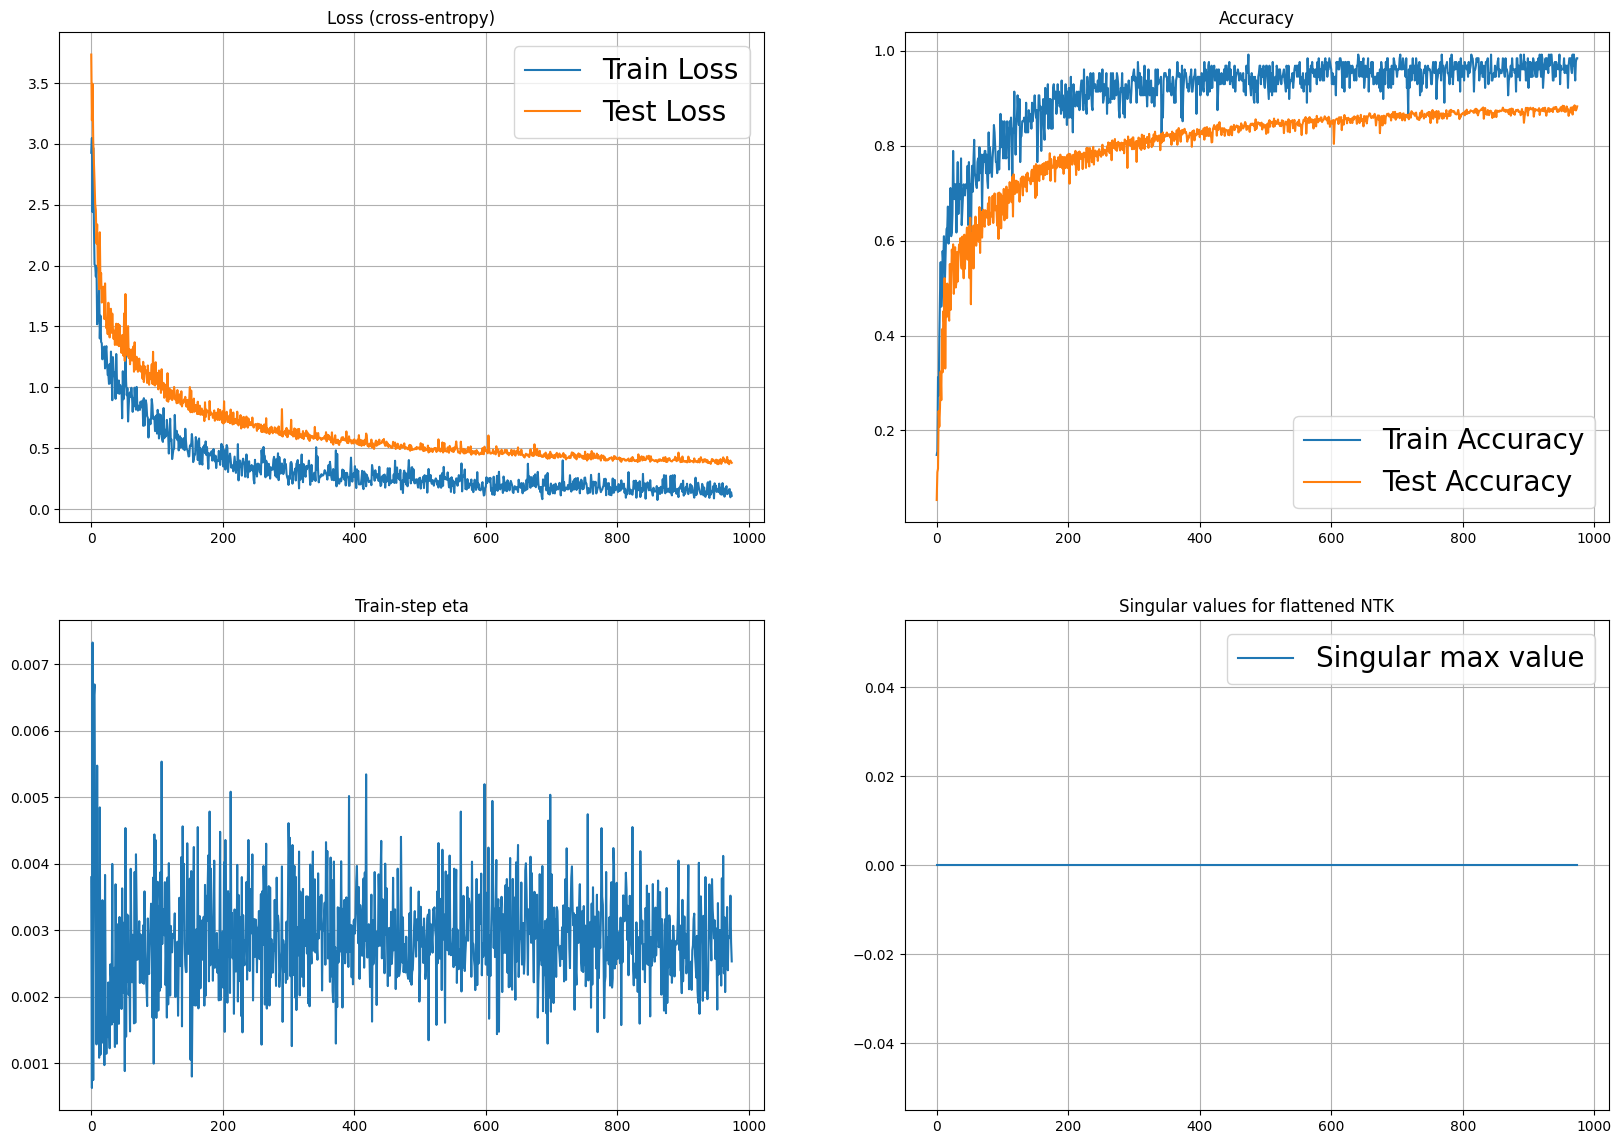

On epoch = 0 test accuracy = 0.883004217791411


In [10]:
#stepCalcZhL = StepCalculatorZhangLambda(meta)
#stepCalcZhS = StepCalculatorZhangSimplified(meta)
#stepCalcSoftmax1 = StepCalculatorEtaSoftmaxArmihoNorm1Base(meta)
stepCalcSoftmax2 = StepCalculatorEtaSoftmaxArmihoNorm2Base(meta)
for epoch in range(NUM_EPOCH):
    # training loop
    iter_number = 0
    for train_batch in train_dataloader:
        iter_number += 1
        images, labels_raw = train_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)

        with torch.no_grad():
            logits = testNet.forward_(xx)
            logits_detached = logits.detach().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0))
            qq_active = reduce_to_active(qq, pp)

        qq_active_avg = np.average(qq_active)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg))
        #if qq_active_avg > 0.3:
        logging.info("##Step with Softmax2 optim")
        eta, logits_latest = stepCalcSoftmax2.step(testNet, logits_detached, labels, xx)
        #else:
        logits_latest = logits_latest.detach()

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)
        # save average train loss and accuracy
        HISTORY_PARAMS_N2SIMPLE['train_loss'].append(loss)
        HISTORY_PARAMS_N2SIMPLE['train_accuracy'].append(calculate_accuracy(prediction,labels))
        HISTORY_PARAMS_N2SIMPLE['train_eta'].append(eta)
        HISTORY_PARAMS_N2SIMPLE['train_ntk_sungular_max'].append(0)

        # testing loop
        test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
        for test_batch in test_dataloader:
            images, labels_raw = test_batch
            labels = torch.tensor([x-1 for x in labels_raw])
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.no_grad():
                batch_size = images.shape[0]
                xx = images.view(batch_size, -1)
                logits = testNet.forward_(xx)

                zz_logits = np.transpose(logits.detach().numpy())
                prediction = logits.argmax(dim=-1).detach()
                loss = loss_crossentropy(zz_logits, labels)
                test_loss_meter.update(loss)
                test_accuracy_meter.update(calculate_accuracy(prediction, labels))

        # save average test accuracy loss and accuracy
        HISTORY_PARAMS_N2SIMPLE['test_loss'].append(test_loss_meter.avg)
        HISTORY_PARAMS_N2SIMPLE['test_accuracy'].append(test_accuracy_meter.avg)
        
        visualise(HISTORY_PARAMS_N2SIMPLE)
        print("On epoch = {} test accuracy = {}".format(epoch, test_accuracy_meter.avg))


#### Experiment 2: FFN with criticality-relu; adaptive step with straight_line, direct parameters update, λ_μν=I

In [11]:
HISTORY_PARAMS_ZHSIMPLE = collections.defaultdict(list)

testNet = MNISTReLU(meta)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
testNet.init_weights(cb, cw)
testNet.to(DEVICE)

FeedForwardNet created with n0=784, nk=0, nl=26, l=0, bias_on=True


MNISTReLU(
  (input_fc): Linear(in_features=784, out_features=1000, bias=True)
  (hidden_fc): Linear(in_features=1000, out_features=400, bias=True)
  (output_fc): Linear(in_features=400, out_features=26, bias=True)
)

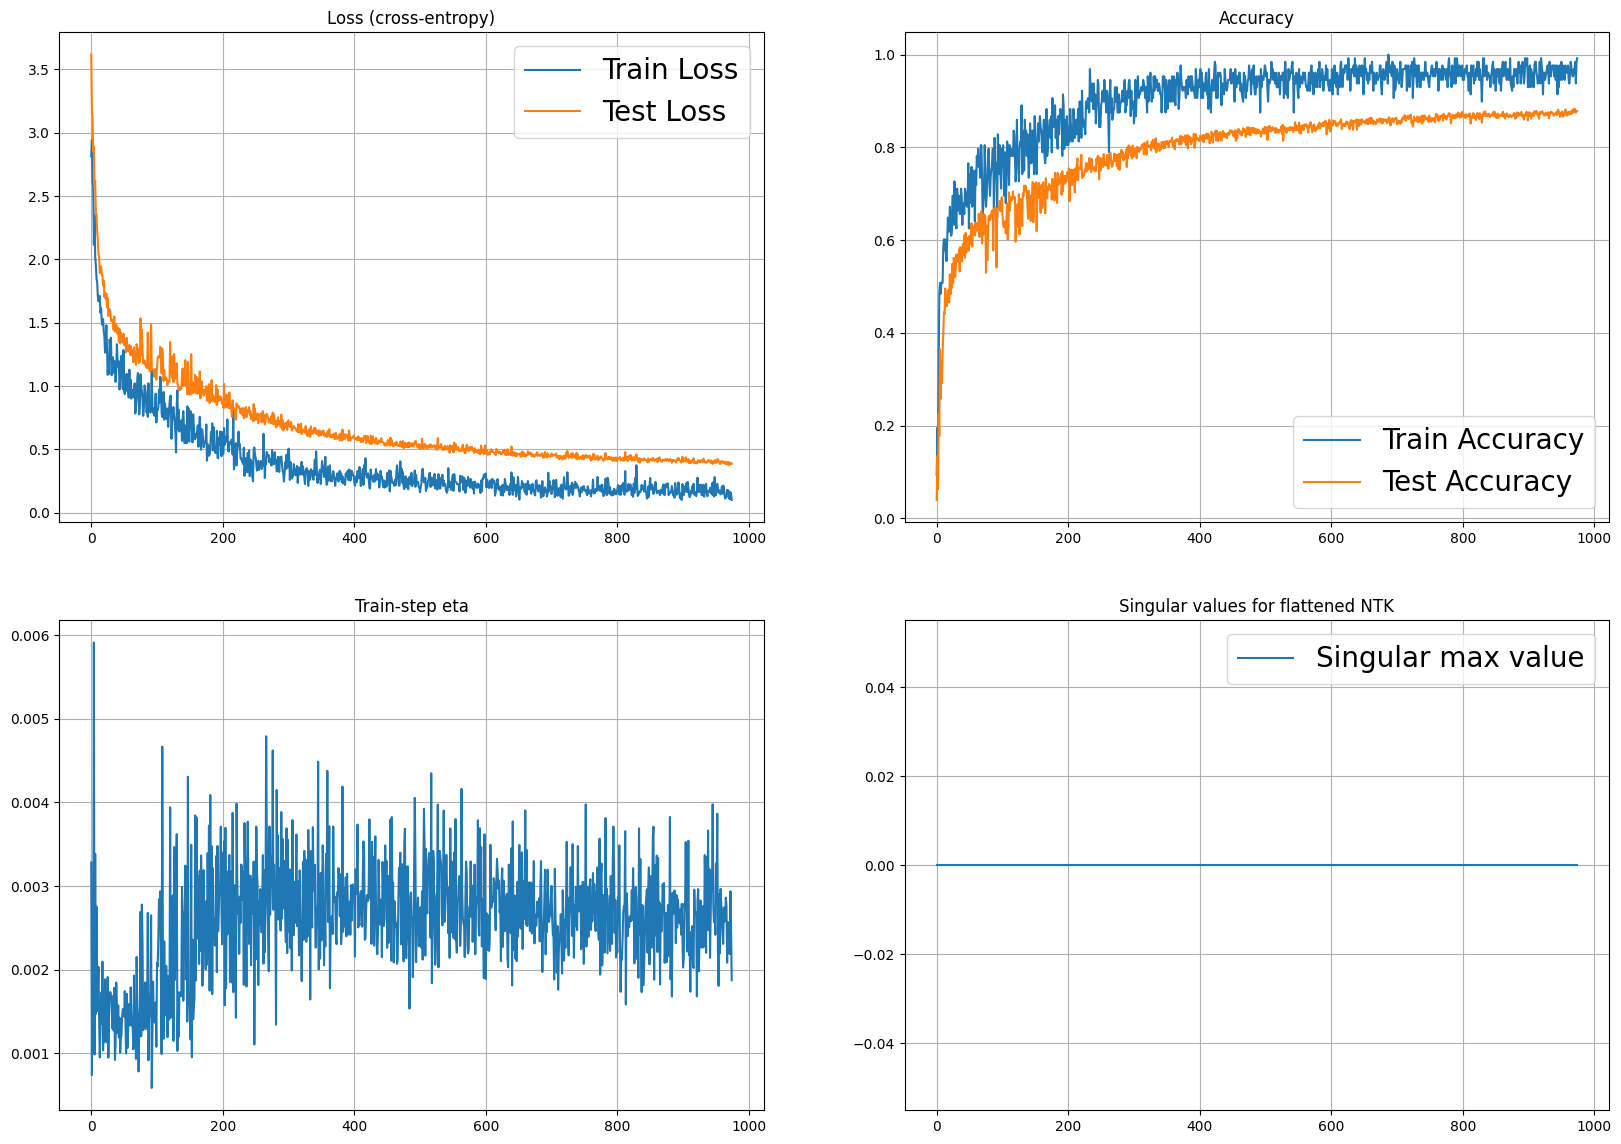

Test accuracy = 0.8783550613496932


In [12]:
stepCalcZh1 = StepCalculatorZhangSimplified(meta)
for epoch in range(NUM_EPOCH):
    # training loop
    iter_number = 0
    for train_batch in train_dataloader:
        iter_number += 1
        images, labels_raw = train_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)
        with torch.no_grad():
            logits = testNet.forward_(xx)
            logits_detached = logits.detach().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0))
            qq_active = reduce_to_active(qq, pp)

        qq_active_avg = np.average(qq_active)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg))
        logging.info("##Step with Zhang simplified optim")
        eta, logits_latest = stepCalcZh1.step(testNet, logits_detached, labels, xx)
        logits_latest = logits_latest.detach()

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)

        # save average train loss and accuracy
        HISTORY_PARAMS_ZHSIMPLE['train_loss'].append(loss)
        HISTORY_PARAMS_ZHSIMPLE['train_accuracy'].append(calculate_accuracy(prediction,labels))
        HISTORY_PARAMS_ZHSIMPLE['train_eta'].append(eta)
        HISTORY_PARAMS_ZHSIMPLE['train_ntk_sungular_max'].append(0)

        # testing loop
        test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
        for test_batch in test_dataloader:
            images, labels_raw = test_batch
            labels = torch.tensor([x-1 for x in labels_raw])
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.no_grad():
                batch_size = images.shape[0]
                xx = images.view(batch_size, -1)
                logits = testNet.forward_(xx)

                zz_logits = np.transpose(logits.detach().numpy())
                prediction = logits.argmax(dim=-1).detach()
                loss = loss_crossentropy(zz_logits, labels)
                test_loss_meter.update(loss)
                test_accuracy_meter.update(calculate_accuracy(prediction, labels))

        # save average test accuracy loss and accuracy
        HISTORY_PARAMS_ZHSIMPLE['test_loss'].append(test_loss_meter.avg)
        HISTORY_PARAMS_ZHSIMPLE['test_accuracy'].append(test_accuracy_meter.avg)
        
        visualise(HISTORY_PARAMS_ZHSIMPLE)
        print("Test accuracy = {}".format(test_accuracy_meter.avg))


#### Experiment 3: FFN with criticality-relu; adaptive step with straight_line, direct parameters update, λ_μν is calculated for criticality

In [13]:
HISTORY_PARAMS_ZHLAMBDA = collections.defaultdict(list)

testNet = MNISTReLU(meta)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
testNet.init_weights(cb, cw)
testNet.to(DEVICE)

FeedForwardNet created with n0=784, nk=0, nl=26, l=0, bias_on=True


MNISTReLU(
  (input_fc): Linear(in_features=784, out_features=1000, bias=True)
  (hidden_fc): Linear(in_features=1000, out_features=400, bias=True)
  (output_fc): Linear(in_features=400, out_features=26, bias=True)
)

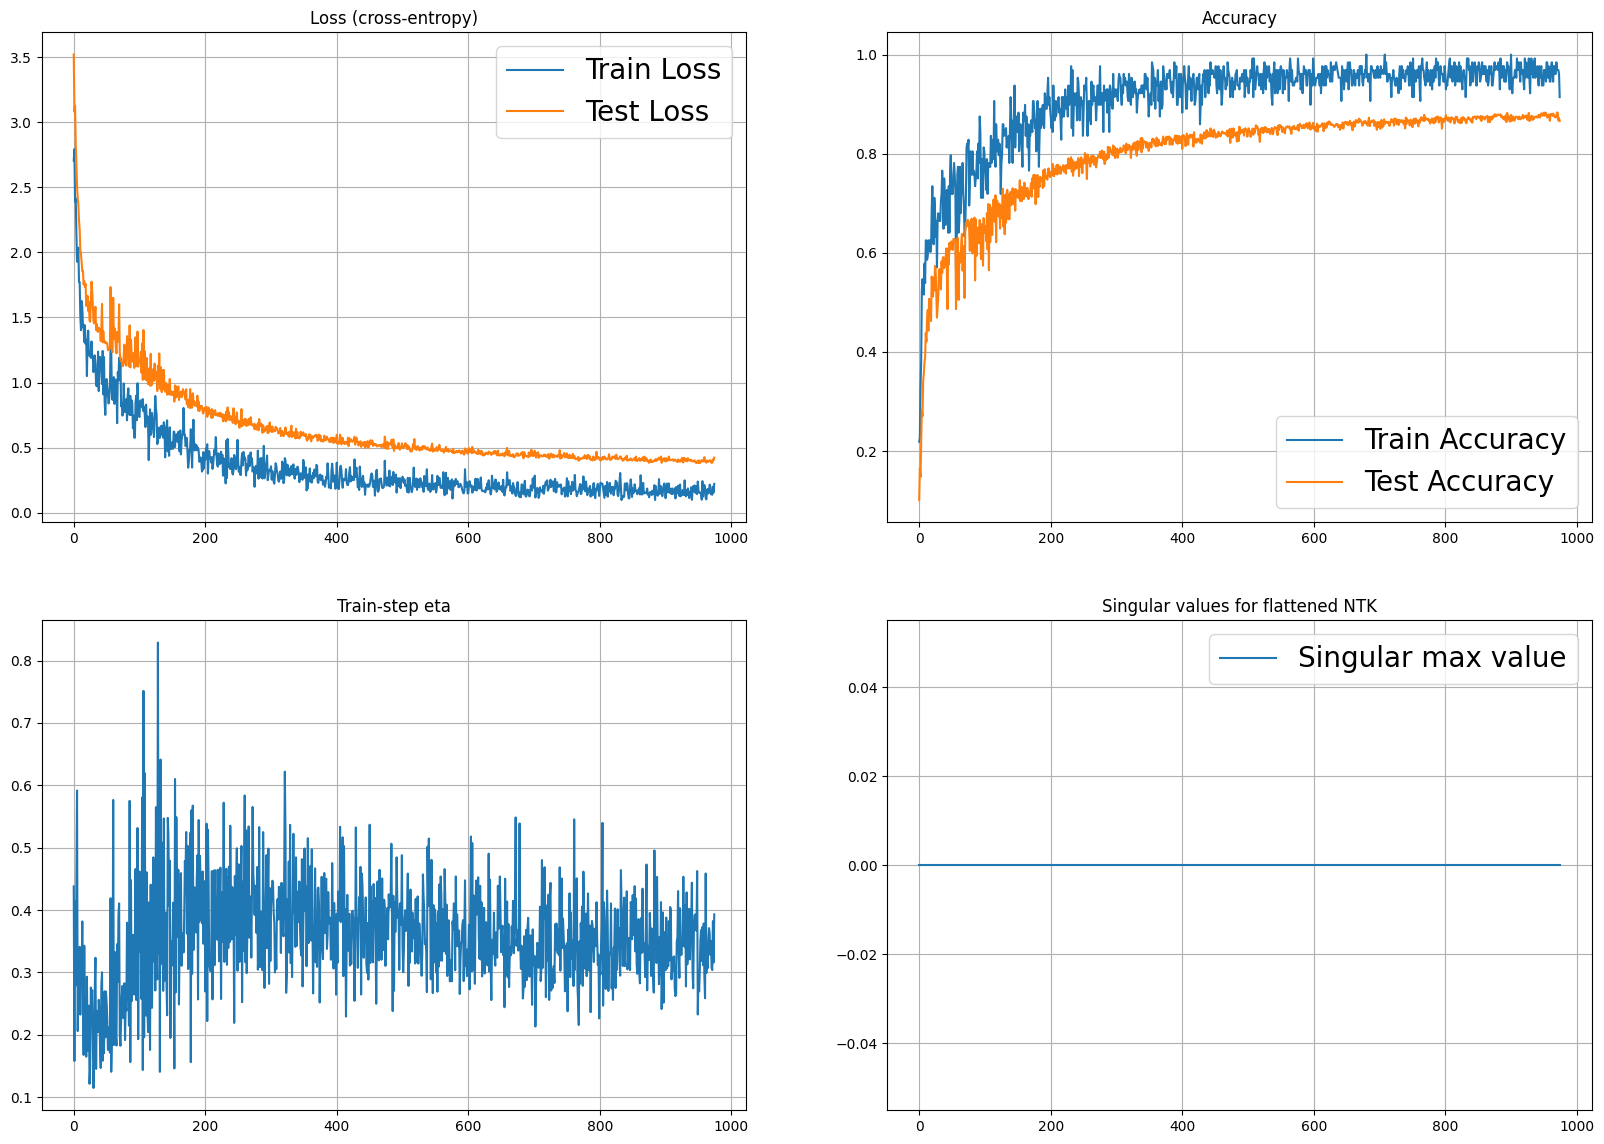

Test accuracy = 0.8658454754601227


In [14]:
stepCalcZh1 = StepCalculatorZhangLambda(meta)
for epoch in range(NUM_EPOCH):
    # training loop
    iter_number = 0
    for train_batch in train_dataloader:
        iter_number += 1
        images, labels_raw = train_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)
        with torch.no_grad():
            logits = testNet.forward_(xx)
            logits_detached = logits.detach().numpy()
            pp = labels_to_softhot(labels, meta.output_dim)
            qq = softmax(np.transpose(logits_detached), axis=(0))
            qq_active = reduce_to_active(qq, pp)

        qq_active_avg = np.average(qq_active)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg))
        logging.info("##Step with Zhang simplified optim")
        eta, logits_latest = stepCalcZh1.step(testNet, logits_detached, labels, xx)
        logits_latest = logits_latest.detach()

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)

        # save average train loss and accuracy
        HISTORY_PARAMS_ZHLAMBDA['train_loss'].append(loss)
        HISTORY_PARAMS_ZHLAMBDA['train_accuracy'].append(calculate_accuracy(prediction,labels))
        HISTORY_PARAMS_ZHLAMBDA['train_eta'].append(eta)
        HISTORY_PARAMS_ZHLAMBDA['train_ntk_sungular_max'].append(0)

        # testing loop
        test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
        for test_batch in test_dataloader:
            images, labels_raw = test_batch
            labels = torch.tensor([x-1 for x in labels_raw])
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.no_grad():
                batch_size = images.shape[0]
                xx = images.view(batch_size, -1)
                logits = testNet.forward_(xx)

                zz_logits = np.transpose(logits.detach().numpy())
                prediction = logits.argmax(dim=-1).detach()
                loss = loss_crossentropy(zz_logits, labels)
                test_loss_meter.update(loss)
                test_accuracy_meter.update(calculate_accuracy(prediction, labels))

        # save average test accuracy loss and accuracy
        HISTORY_PARAMS_ZHLAMBDA['test_loss'].append(test_loss_meter.avg)
        HISTORY_PARAMS_ZHLAMBDA['test_accuracy'].append(test_accuracy_meter.avg)
        
        visualise(HISTORY_PARAMS_ZHLAMBDA)
        print("Test accuracy = {}".format(test_accuracy_meter.avg))


#### Experiment 4: FFN with criticality-relu; fixed eta=0.01, parameters are updated via torch.SGD

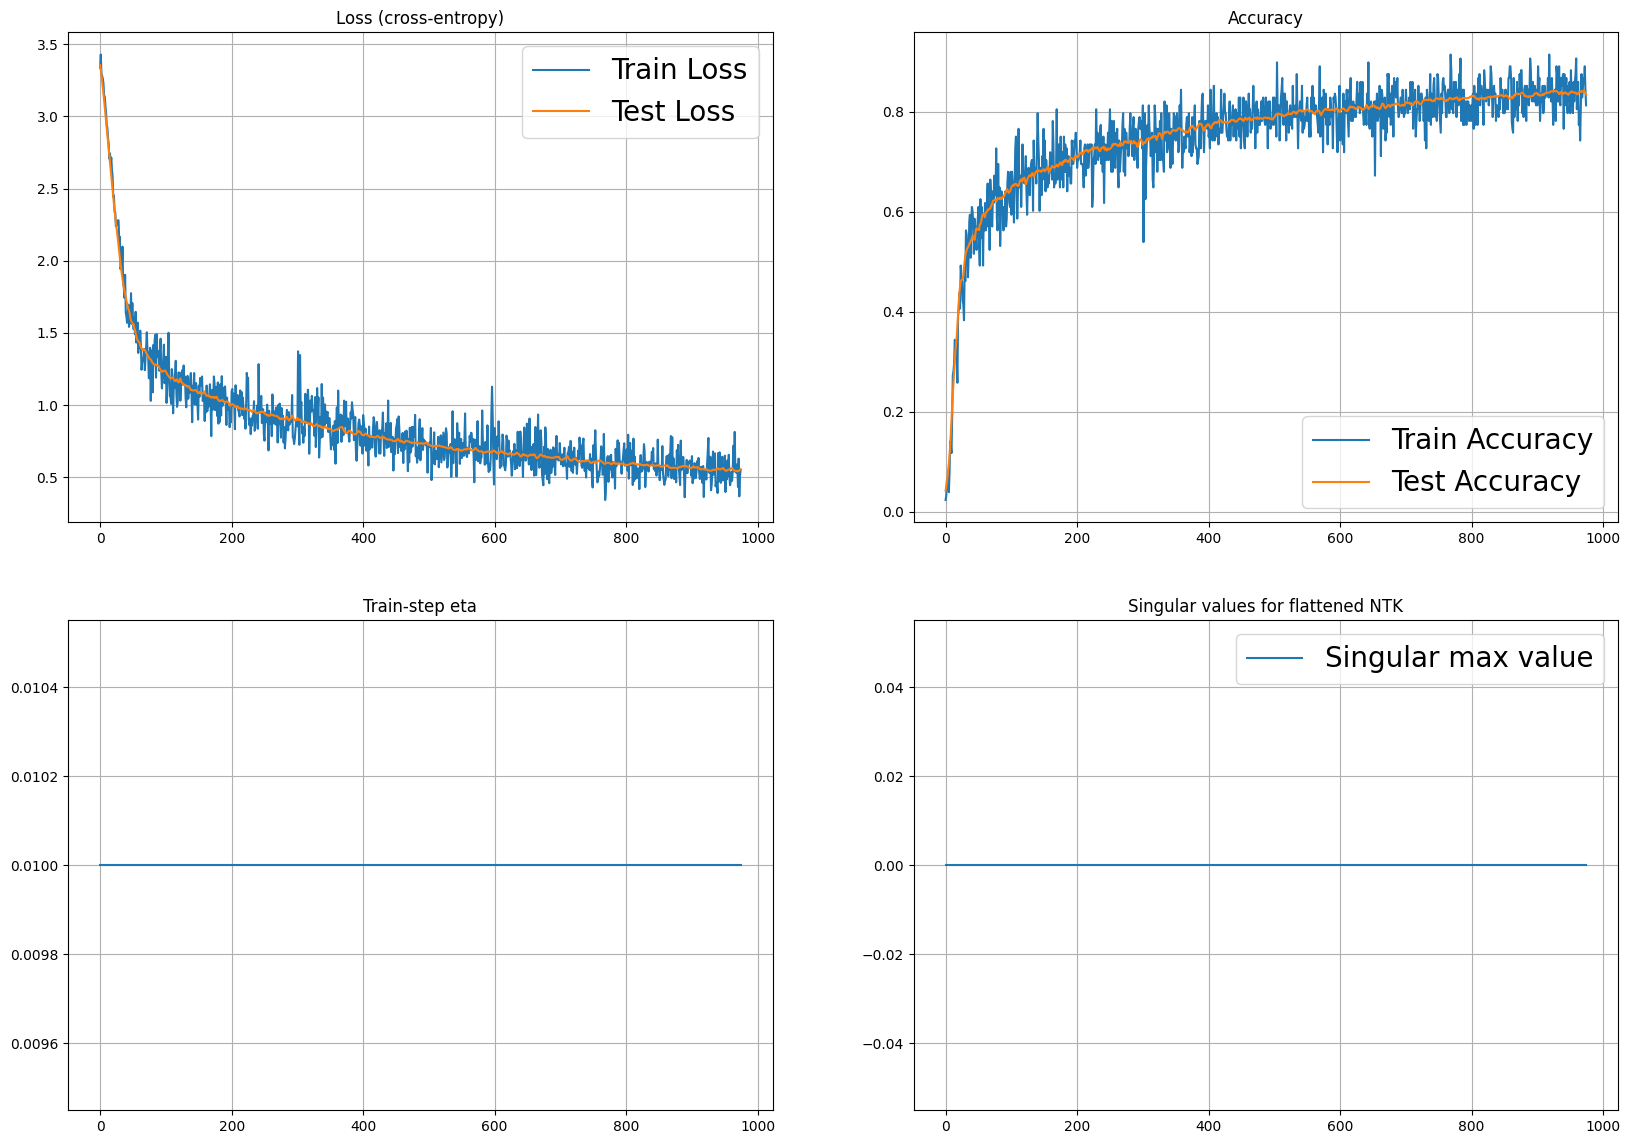

Test accuracy = 0.8344516871165644


In [15]:
HISTORY_CRITICALITY = collections.defaultdict(list)

testNet = MNISTReLU(meta)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
testNet.init_weights(cb, cw)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(testNet.parameters(), lr=1e-2, momentum=0.9, nesterov=True) #, momentum=0.9, nesterov=True)

DEVICE = torch.device('cpu')  # you can change to `cuda:0`
testNet.to(DEVICE)

for epoch in range(NUM_EPOCH):
    # AverageMeter will accumulate average of some metric
    # Check implementation in `utils.py`
    train_loss_meter, train_accuracy_meter, test_loss_meter, test_accuracy_meter = \
        AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()
    
    # training loop
    for train_batch in train_dataloader:
        
        # unpack batch and move to specific device (for example, GPU or TPU)
        images, labels_raw = train_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)
        logits = testNet.forward_(xx)
        prediction = logits.argmax(dim=-1)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        #testNet.output_fc.backward()
        optimizer.step()

        # save average train loss and accuracy
        HISTORY_CRITICALITY['train_loss'].append(loss.item())
        HISTORY_CRITICALITY['train_accuracy'].append(calculate_accuracy(prediction.detach(),labels))
        HISTORY_CRITICALITY['train_eta'].append(1e-2)
        HISTORY_CRITICALITY['train_ntk_sungular_max'].append(0)

        # testing loop
        test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
        for test_batch in test_dataloader:
            images, labels_raw = test_batch
            labels = torch.tensor([x-1 for x in labels_raw])
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.no_grad():
                batch_size = images.shape[0]
                xx = images.view(batch_size, -1)
                logits = testNet.forward_(xx)

                zz_logits = np.transpose(logits.detach().numpy())
                prediction = logits.argmax(dim=-1).detach()
                loss = loss_crossentropy(zz_logits, labels)
                test_loss_meter.update(loss)
                test_accuracy_meter.update(calculate_accuracy(prediction, labels))

        # save average test accuracy loss and accuracy
        HISTORY_CRITICALITY['test_loss'].append(test_loss_meter.avg)
        HISTORY_CRITICALITY['test_accuracy'].append(test_accuracy_meter.avg)
        
        visualise(HISTORY_CRITICALITY)
        print("Test accuracy = {}".format(test_accuracy_meter.avg))


#### Experiment 5: FFN with criticality-relu; adaptive step with Zhang-simplified alg, parameters are updated via torch.SGD, λ_μν=I

In [16]:
HISTORY_OPTIMISER_ZHSIMPLE = collections.defaultdict(list)

testNet = MNISTReLU(meta)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
testNet.init_weights(cb, cw)
testNet.to(DEVICE)

FeedForwardNet created with n0=784, nk=0, nl=26, l=0, bias_on=True


MNISTReLU(
  (input_fc): Linear(in_features=784, out_features=1000, bias=True)
  (hidden_fc): Linear(in_features=1000, out_features=400, bias=True)
  (output_fc): Linear(in_features=400, out_features=26, bias=True)
)

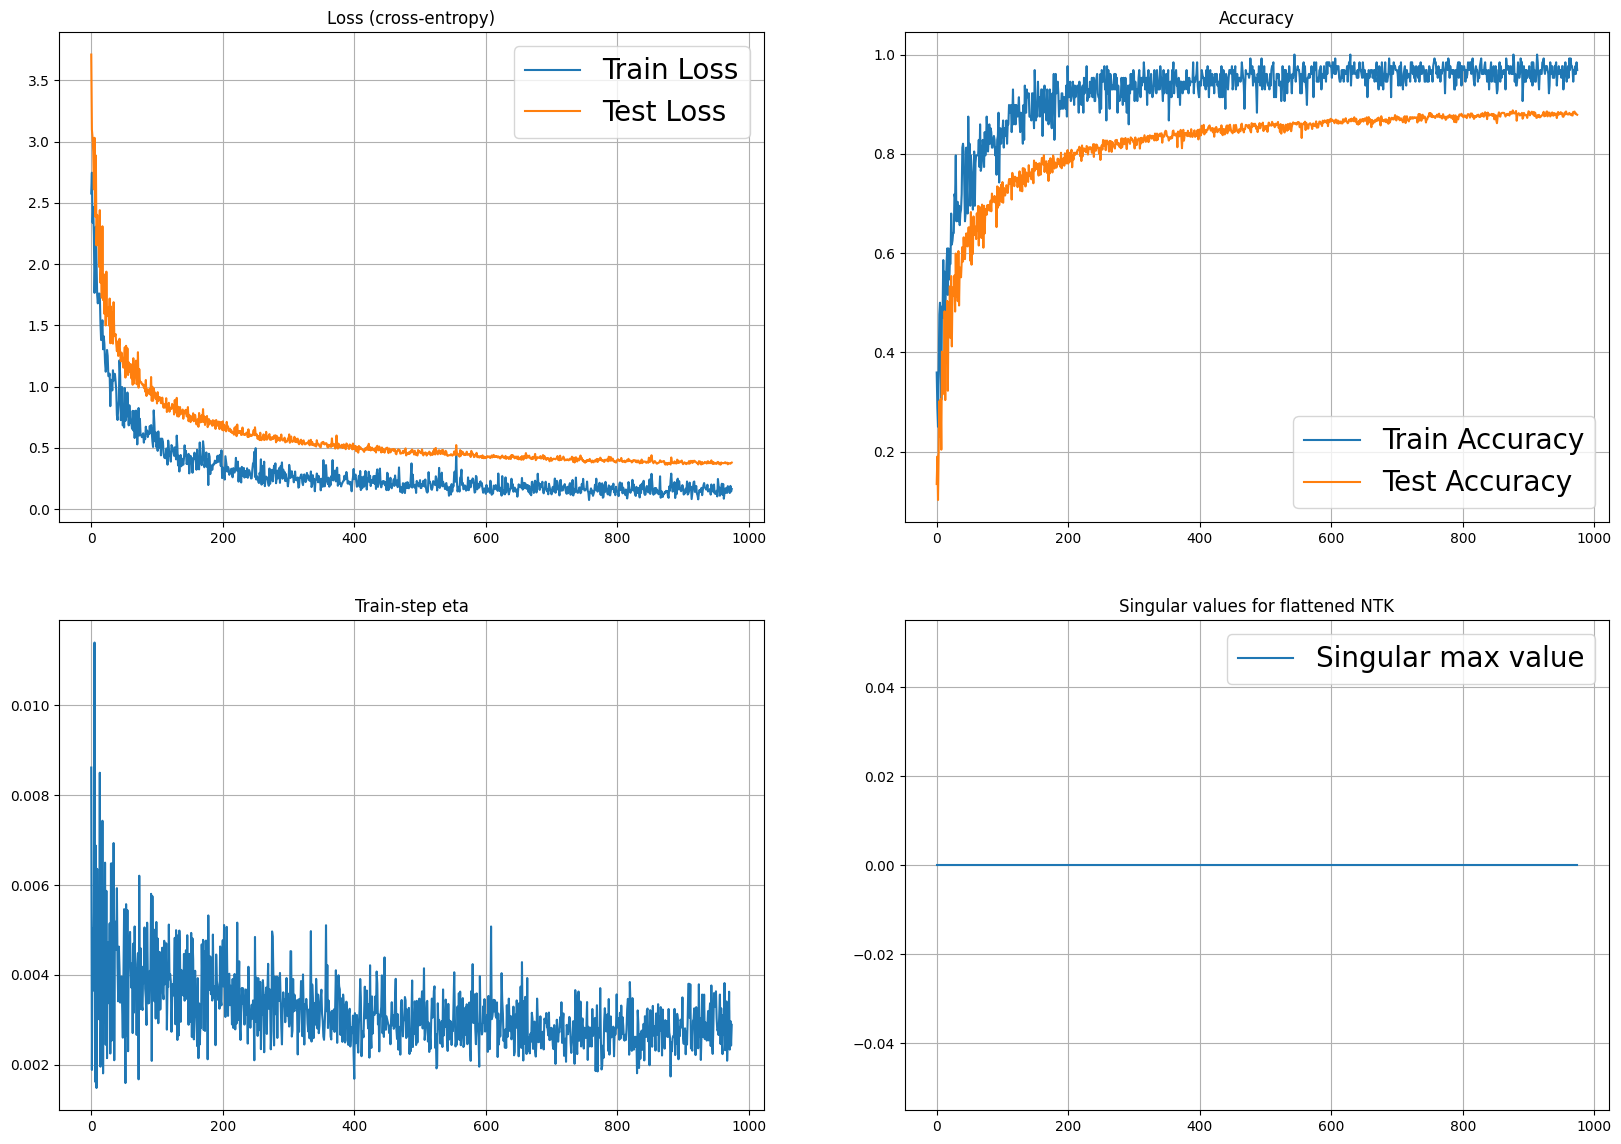

On epoch = 0 test accuracy = 0.8786426380368099


In [17]:
stepCalcZh = StepCalculatorZhangSimplified(meta)
stepCalcSoftmax = StepCalculatorEtaSoftmaxArmihoNorm2(meta)
loss_fn = nn.CrossEntropyLoss(reduction='sum')
#loss_fnSoftmax = torch.linalg.matrix_norm(1-nn.LogSoftmax(dim=1), ord='fro')
optimizer = optim.SGD(testNet.parameters(), lr=1e-2)
for epoch in range(NUM_EPOCH):
    # training loop
    iter_number = 0
    for train_batch in train_dataloader:
        iter_number += 1
        images, labels_raw = train_batch
        labels = labels_raw - 1 #torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)

        with torch.no_grad():
            logits = testNet.forward_(xx)

        logits_detached = logits.detach().numpy()
        pp = labels_to_softhot(labels, meta.output_dim)
        qq = softmax(np.transpose(logits_detached), axis=(0))
        qq_active = reduce_to_active(qq, pp)

        qq_active_avg = np.average(qq_active)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), qq_active_avg))
        if qq_active_avg > 0.000000090:
            logging.info("##Step with Zhang optim")
            optimizer.zero_grad()
            logits = testNet.forward_(xx)
            loss = loss_fn(logits, labels)
            loss.backward()
            eta = stepCalcZh.calc_eta(testNet, loss.item())
        else:
            logging.info("##Step with norm2 optim")
            #optimizer.zero_grad()
            #testNet.forward_(xx)
            '''
            testNet2 = MNISTReLU(meta)
            testNet.save_txt("tmp")
            testNet2.init_weights_txt('tmp')
            testNet2.set_slopes(slope_plus, slope_minus)
            testNet2.forward_(xx)
            eta = stepCalcSoftmax.calc_eta(testNet2, xx, pp, qq) #.step(testNet, logits_detached, labels, xx)
            '''
            eta = 0.01
            optimizer.zero_grad()
            logits = testNet.forward_(xx)
            loss = loss_fn(logits, labels)
            loss.backward()
        optimizer.param_groups[0]['lr'] = eta # set learning rate
        optimizer.step()
        with torch.no_grad():
            logits_latest = testNet.forward_(xx)
        logits_latest = logits_latest.detach()

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)
        # save average train loss and accuracy
        HISTORY_OPTIMISER_ZHSIMPLE['train_loss'].append(loss)
        HISTORY_OPTIMISER_ZHSIMPLE['train_accuracy'].append(calculate_accuracy(prediction,labels))
        HISTORY_OPTIMISER_ZHSIMPLE['train_eta'].append(eta)
        HISTORY_OPTIMISER_ZHSIMPLE['train_ntk_sungular_max'].append(0)

        # testing loop
        test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
        for test_batch in test_dataloader:
            images, labels_raw = test_batch
            labels = torch.tensor([x-1 for x in labels_raw])
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.no_grad():
                batch_size = images.shape[0]
                xx = images.view(batch_size, -1)
                logits = testNet.forward_(xx)

                zz_logits = np.transpose(logits.detach().numpy())
                prediction = logits.argmax(dim=-1).detach()
                loss = loss_crossentropy(zz_logits, labels)
                test_loss_meter.update(loss)
                test_accuracy_meter.update(calculate_accuracy(prediction, labels))

        # save average test accuracy loss and accuracy
        HISTORY_OPTIMISER_ZHSIMPLE['test_loss'].append(test_loss_meter.avg)
        HISTORY_OPTIMISER_ZHSIMPLE['test_accuracy'].append(test_accuracy_meter.avg)
        
        visualise(HISTORY_OPTIMISER_ZHSIMPLE)
        print("On epoch = {} test accuracy = {}".format(epoch, test_accuracy_meter.avg))




#### Comparison

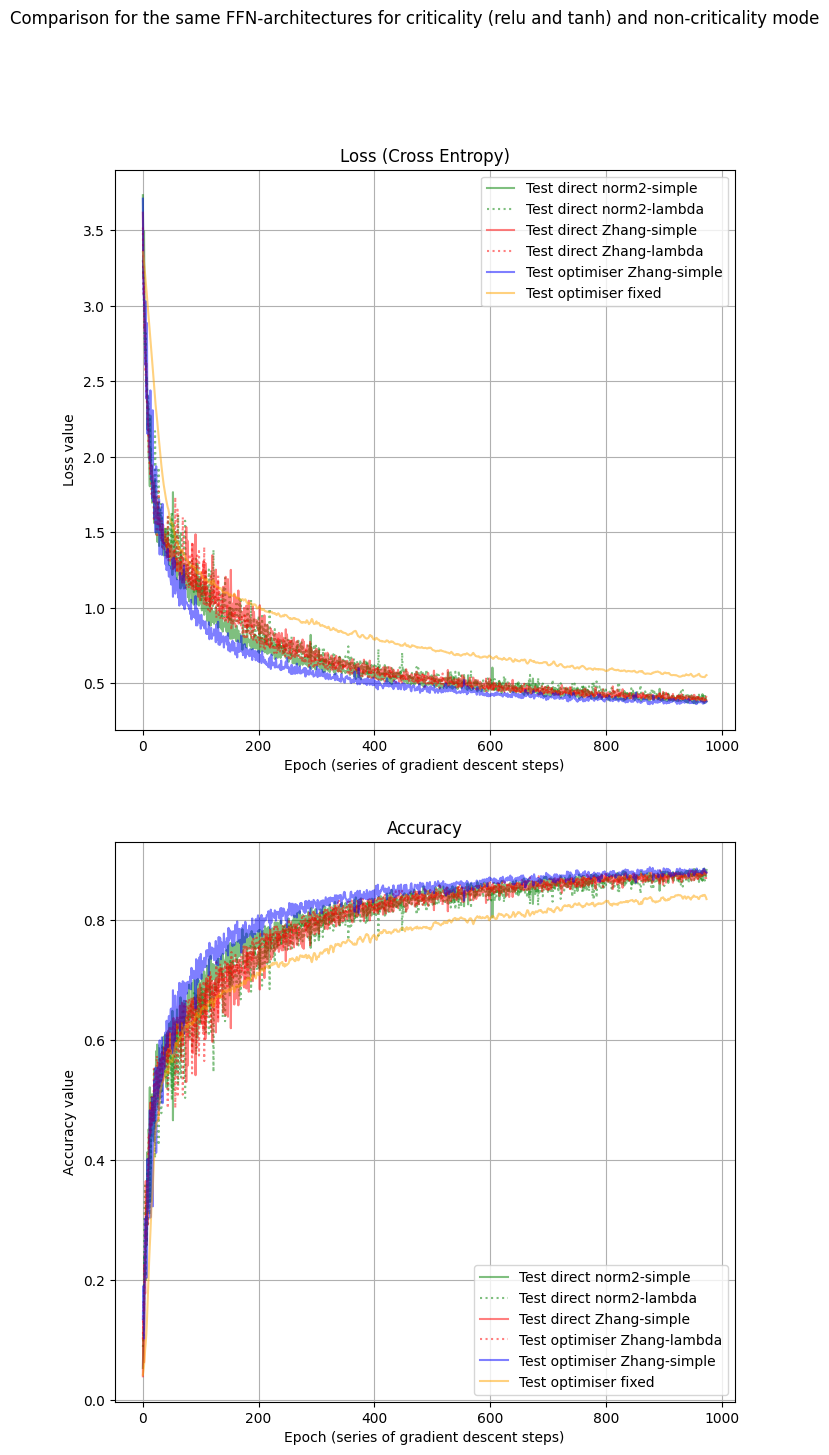

In [18]:
STEP_START, STEP_STOP = 0, 1000
display.clear_output()
fig, axes = plt.subplots(2, 1, figsize=(8, 16))
axes[0].set_title('Loss (Cross Entropy)')
#axes[0].plot(HISTORY_PARAMS_N2LAMBDA['train_loss'][STEP_START:STEP_STOP], color='g', ls='dotted', alpha=.5, label='Train direct composed')
#axes[0].plot(HISTORY_OPTIMISER_ZHSIMPLE['train_loss'][STEP_START:STEP_STOP], color='b', ls='dotted', alpha=.5, label='Train optimiser Zhang-simple')
#axes[0].plot(HISTORY_PARAMS_ZHSIMPLE['train_loss'][STEP_START:STEP_STOP], color='r', ls='dotted', alpha=.5, label='Train direct Zhang-simple')
#axes[0].plot(HISTORY_CRITICALITY['train_loss'][STEP_START:STEP_STOP], color='orange', ls='dotted', alpha=.5, label='Train optimiser fixed')
#axes[0].plot(HISTORY_PARAMS_ZHLAMBDA['train_loss'][STEP_START:STEP_STOP], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
axes[0].plot(HISTORY_PARAMS_N2SIMPLE['test_loss'][STEP_START:STEP_STOP], color='g', alpha=.5, label='Test direct norm2-simple')
axes[0].plot(HISTORY_PARAMS_N2LAMBDA['test_loss'][STEP_START:STEP_STOP], color='g', ls='dotted', alpha=.5, label='Test direct norm2-lambda')
axes[0].plot(HISTORY_PARAMS_ZHSIMPLE['test_loss'][STEP_START:STEP_STOP], color='r', alpha=.5, label='Test direct Zhang-simple')
axes[0].plot(HISTORY_PARAMS_ZHLAMBDA['test_loss'][STEP_START:STEP_STOP], color='r', ls='dotted', alpha=.5, label='Test direct Zhang-lambda')
axes[0].plot(HISTORY_OPTIMISER_ZHSIMPLE['test_loss'][STEP_START:STEP_STOP], color='b', alpha=.5, label='Test optimiser Zhang-simple')
axes[0].plot(HISTORY_CRITICALITY['test_loss'][STEP_START:STEP_STOP], color='orange', alpha=.5, label='Test optimiser fixed')
axes[0].grid()
axes[0].legend()
axes[0].set_xlabel("Epoch (series of gradient descent steps)")
axes[0].set_ylabel("Loss value")

axes[1].set_title('Accuracy')
#axes[1].plot(HISTORY_PARAMS_N2LAMBDA['train_accuracy'][STEP_START:STEP_STOP], color='g', alpha=.5, ls='dotted', label='Train direct composed')
#axes[1].plot(HISTORY_OPTIMISER_ZHSIMPLE['train_accuracy'][STEP_START:STEP_STOP], color='b', alpha=.5, ls='dotted', label='Train optimiser Zhang-simple')
#axes[1].plot(HISTORY_PARAMS_ZHSIMPLE['train_accuracy'][STEP_START:STEP_STOP], color='r', alpha=.5, ls='dotted', label='Train direct Zhang-simple')
#axes[1].plot(HISTORY_CRITICALITY['train_accuracy'][STEP_START:STEP_STOP], color='orange', alpha=.5, ls='dotted', label='Train optimiser fixed')
#axes[1].plot(HISTORY_PARAMS_ZHLAMBDA['train_accuracy'][STEP_START:STEP_STOP], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
axes[1].plot(HISTORY_PARAMS_N2SIMPLE['test_accuracy'][STEP_START:STEP_STOP], color='g', alpha=.5, label='Test direct norm2-simple')
axes[1].plot(HISTORY_PARAMS_N2LAMBDA['test_accuracy'][STEP_START:STEP_STOP], color='g', ls='dotted', alpha=.5, label='Test direct norm2-lambda')
axes[1].plot(HISTORY_PARAMS_ZHSIMPLE['test_accuracy'][STEP_START:STEP_STOP], color='r', alpha=.5, label='Test direct Zhang-simple')
axes[1].plot(HISTORY_PARAMS_ZHLAMBDA['test_accuracy'][STEP_START:STEP_STOP], color='r', ls='dotted', alpha=.5, label='Test optimiser Zhang-lambda')
axes[1].plot(HISTORY_OPTIMISER_ZHSIMPLE['test_accuracy'][STEP_START:STEP_STOP], color='b', alpha=.5, label='Test optimiser Zhang-simple')
axes[1].plot(HISTORY_CRITICALITY['test_accuracy'][STEP_START:STEP_STOP], color='orange', alpha=.5, label='Test optimiser fixed')
axes[1].grid()
axes[1].legend()
axes[1].set_xlabel("Epoch (series of gradient descent steps)")
axes[1].set_ylabel("Accuracy value")

dummy=fig.suptitle("Comparison for the same FFN-architectures for criticality (relu and tanh) and non-criticality mode")

plt.show()